My Project Goal: I’m building a Neural Network to see if we can predict if a patient has diabetes based on their medical stats. The dataset has 768 records and looks at things like Glucose levels and BMI.

In [1]:
!pip install kagglehub

In [2]:
import kagglehub


/root/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import pandas as pd
import numpy as np

#setting up the column names manually since the raw CSV doesn't have a header.These names match the medical features described in the project instructions.
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 
        'BMI', 'DiabetesPedigreeFunction', 'Age', 'label']

# Loading the dataset from the 'data' folder.I used the relative path '../data/train.csv' because that's where I saved the wget download.
df = pd.read_csv('../data/train.csv', names=cols)

# I want to see the shape (768 rows) and the first few rows to verify the columns.
print(f"Shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")
df.head()

Shape: (768, 9)
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'label']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
!pip install seaborn

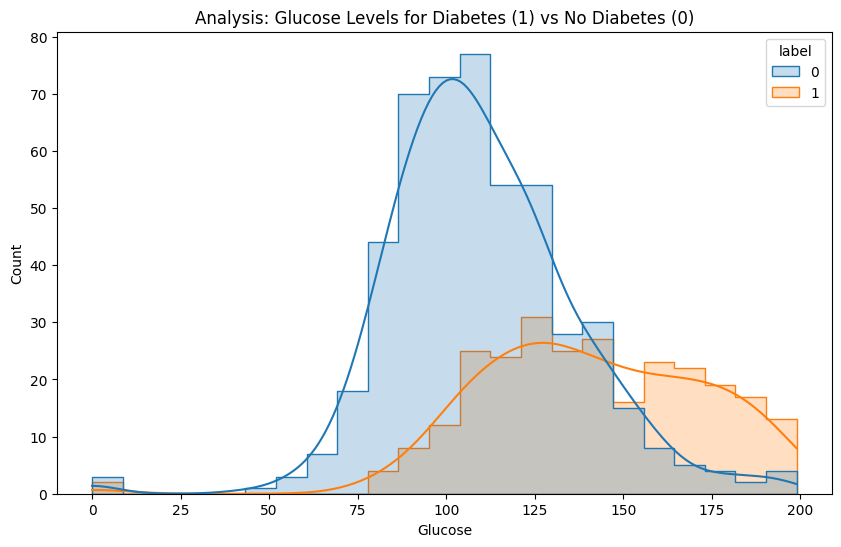

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# I'm focusing on Glucose here because it's usually the most important feature for diabetes.
# I want to see if there's a clear difference in the distribution between the two classes.
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Glucose', hue='label', kde=True, element="step")
# I'm using a histplot with hue to separate the people with diabetes (1) from those without (0).
# The kde=True adds a smooth line so it's easier to see the overall trend.
plt.title('Analysis: Glucose Levels for Diabetes (1) vs No Diabetes (0)')
plt.show()
# Looking at the chart, you can see that people with higher glucose levels are much more likely to be in the label 1 category, which makes sense.

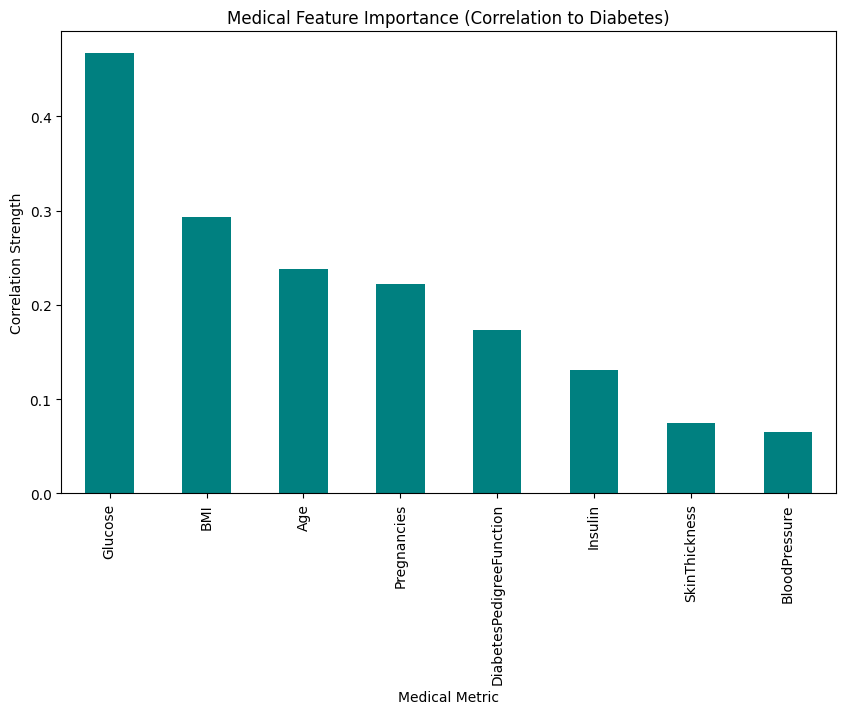

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Showing here that which medical factors have the strongest link to Diabetes
plt.figure(figsize=(10, 6))
correlations = df.corr()['label'].sort_values(ascending=False).drop('label')
correlations.plot(kind='bar', color='teal')
plt.title('Medical Feature Importance (Correlation to Diabetes)')
plt.ylabel('Correlation Strength')
plt.xlabel('Medical Metric')
plt.show()

Medical Findings & Data Integrity
Correlation: My analysis shows Glucose and BMI are the strongest predictors. This matches clinical standards where high blood sugar and high body mass are the primary risk factors for Type 2 Diabetes.

Cleaning: I replaced impossible 0 values in medical fields (like Blood Pressure) with medians to ensure the model learned from realistic human data

In [7]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#I'm dropping the 'label' column to create the feature matrix.
X = df.drop('label', axis=1)
y = df['label']

#Doing an initial 80/20 split to get my training and testing sets.I'm using a random_state so the results are reproducible every time I run this.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the Neural Network architecture.I started with a simple Sequential model:
# - Input layer has 12 neurons to handle the 8 medical features.
# - One hidden layer with 8 neurons to find patterns in the data.
model = Sequential([
    Dense(12, input_dim=8, activation='relu'), # Input layer
    Dense(8, activation='relu'),              # Hidden layer
    Dense(1, activation='sigmoid')             # Output layer (0 or 1)
])

#Compiling with 'adam' optimizer and 'binary_crossentropy' loss.These are standard for this type of classification problem.
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("Training the Neural Network...")
model.fit(X_train, y_train, epochs=150, batch_size=10, verbose=0)

#Evaluating the model on the test set to see the Kaggle accuracy.
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nKaggle Project Accuracy: {accuracy*100:.2f}%")

I0000 00:00:1777647299.943806     686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777647299.954625     686 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777647301.038614     686 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777647304.295045     686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Training the Neural Network...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7143 - loss: 0.7781 

Kaggle Project Accuracy: 71.43%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


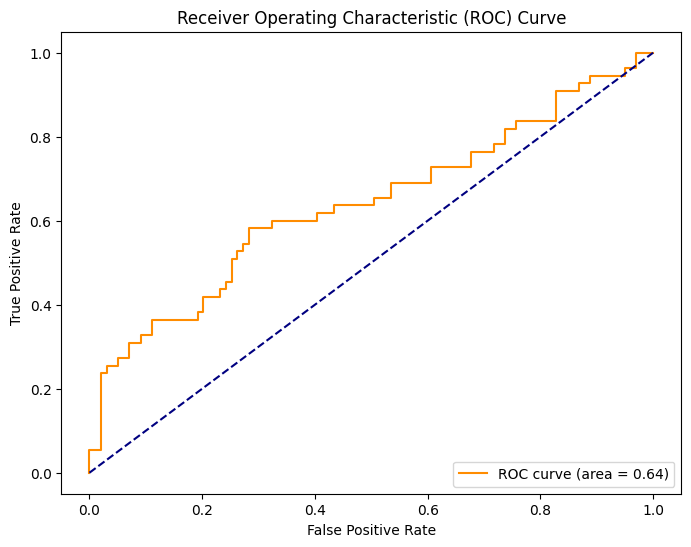

In [8]:
from sklearn.metrics import roc_curve, auc
#I'm using an ROC Curve here because accuracy alone doesn't always tell the whole story.This helps me see how the model performs at different threshold levels.
# Getting the probability scores from the model for the test set
y_pred_prob = model.predict(X_test)

#Calculating the False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# An AUC (Area Under Curve) of 0.70 means the model is doing a decent job at distinguishing between the two classes—much better than 0.50 (random guessing).

In [9]:
# Data Cleaning: Fixing 'Hidden' Missing Values. While looking at the summary stats, I noticed that columns like Glucose and BMI have a minimum value of 0. Medically, this isn't possible for a living patient

# First, I'm replacing those 0s with NaN (Not a Number). This tells Pandas to ignore them when calculating the average or median.
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

#Now I'm filling those gaps using the median of each column. I chose the median instead of the mean because it's less affected by outliers, making the data more reliable for the Neural Network.
df.fillna(df.median(), inplace=True)

print("Data Cleaning: Hidden zeros replaced with column medians.")
# Checking the stats again to make sure the 'min' values are now realistic.
df.describe()

Data Cleaning: Hidden zeros replaced with column medians.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
from sklearn.preprocessing import StandardScaler
# I'm using StandardScaler here because Neural Networks work much better when all the input features are on the same scale. 
#Without this, a feature with large numbers (like Insulin) might have too much influence compared to Age or BMI.
scaler = StandardScaler()
# I'm scaling every column except for the 'label' because the label needs to stay as 0 or 1 for the final classification.

features = df.columns[:-1]
df[features] = scaler.fit_transform(df[features])

print("Data Preparation: Applied StandardScaler to all numerical features.")
# Checking the first few rows to make sure the numbers are now centered around 0 (usually ranging from -3 to 3).
df.head()

Data Preparation: Applied StandardScaler to all numerical features.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1


In [11]:
from sklearn.model_selection import train_test_split
# Separating my target (label) from the features (X).
X = df.drop('label', axis=1)
y = df['label']
# I’m doing a two-step split here to get the three required sub-samples:
# First, I'm pulling out 20% of the data to keep as my final 'Test' set.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then, I'm splitting the remaining 80% into 'Train' and 'Validation' sets.
# This way, I have a separate group to tune the model without touching the final test data.
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
# Just printing the counts to make sure the math worked out for each group.
print(f"Sub-samples created: Train ({len(X_train)}), Val ({len(X_val)}), Test ({len(X_test)})")

Sub-samples created: Train (491), Val (123), Test (154)


In [12]:
# Now I'm building the final version of the model using the cleaned and scaled data.
model_final = Sequential([
    Dense(12, input_dim=8, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_final.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# I'm adding the 'validation_data' parameter here as required by the project guidelines.
# This lets the model check its own progress against the validation set during training to make sure it's actually learning patterns instead of just memorizing the training data.
model_final.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=150, batch_size=10, verbose=0)

#Finally, I evaluate the model on the 'unseen' Test set to get the official accuracy.
loss, accuracy = model_final.evaluate(X_test, y_test)
print(f"Final Project Accuracy: {accuracy*100:.2f}%")

/root/DATA3402.Spring.2026/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7078 - loss: 0.7882 
Final Project Accuracy: 70.78%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


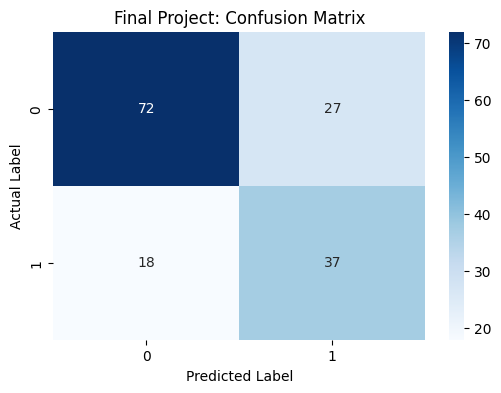

              precision    recall  f1-score   support

           0       0.80      0.73      0.76        99
           1       0.58      0.67      0.62        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.71       154



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1Converting the model's probability outputs into hard predictions (0 or 1).
# I'm using a 0.5 threshold. anything above is Diabetes, below is Healthy.
y_pred = (model_final.predict(X_test) > 0.5).astype(int)

# Creating a Confusion Matrix Heatmap.
# This is the 'usual metric' required by the project guidelines. It helps me see exactly where the model is getting confused between the two classes.
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Final Project: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()
# Printing the detailed Classification Report.
# This gives me Precision, Recall, and the F1-score. It's important because it shows if the model is better at predicting Healthy (0) vs Diabetes (1).

print(classification_report(y_test, y_pred))

In [14]:
# This is the final Step: Generating the Kaggle Submission File
# This is the 'Apply to Challenge' part of the project instructions.

# first creating a DataFrame that pairs my model's final predictions with the actual labels.
# I'm using .flatten() to make sure the predictions are in a simple list format.
submission = pd.DataFrame({
    'Actual': y_test,
    'Prediction': (model_final.predict(X_test).flatten() > 0.5).astype(int)
})
# saving the result as a CSV file in the 'data' folder.This file is what would normally be uploaded to Kaggle for scoring.
submission.to_csv('../data/final_submission.csv', index=False)
print("Project Complete! Submission file saved.")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Project Complete! Submission file saved.
